# Prism vs K₃,₃ — DRESS Demo 👗

The **Prism graph** (C₃ □ K₂) and **K₃,₃** (complete bipartite) are both 3-regular on 6 vertices. They are indistinguishable by **1-WL** (colour refinement).

Standard DRESS (equivalent to 2-WL) tells them apart immediately — no deletion needed.

> **TL;DR:** Same degree sequence, same 1-WL colouring — but DRESS produces different edge fingerprints.

In [1]:
!pip install -q dress-graph networkx matplotlib numpy

In [2]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from dress.networkx import dress_graph

## 1. Build the two 3-regular graphs

In [3]:
# Prism (C3 □ K2): two triangles 0-1-2 and 3-4-5, with spokes 0-3, 1-4, 2-5
prism = nx.Graph()
prism.add_edges_from([(0,1), (1,2), (2,0),   # top triangle
                      (3,4), (4,5), (5,3),   # bottom triangle
                      (0,3), (1,4), (2,5)])  # spokes

# K3,3: complete bipartite {0,1,2} <-> {3,4,5}
k33 = nx.complete_bipartite_graph(3, 3)

print(f"Prism:  {prism.number_of_nodes()} nodes, {prism.number_of_edges()} edges, degrees: {sorted(dict(prism.degree()).values())}")
print(f"K₃,₃:  {k33.number_of_nodes()} nodes, {k33.number_of_edges()} edges, degrees: {sorted(dict(k33.degree()).values())}")

Prism:  6 nodes, 9 edges, degrees: [3, 3, 3, 3, 3, 3]
K₃,₃:  6 nodes, 9 edges, degrees: [3, 3, 3, 3, 3, 3]


## 2. Visualize the graphs side by side

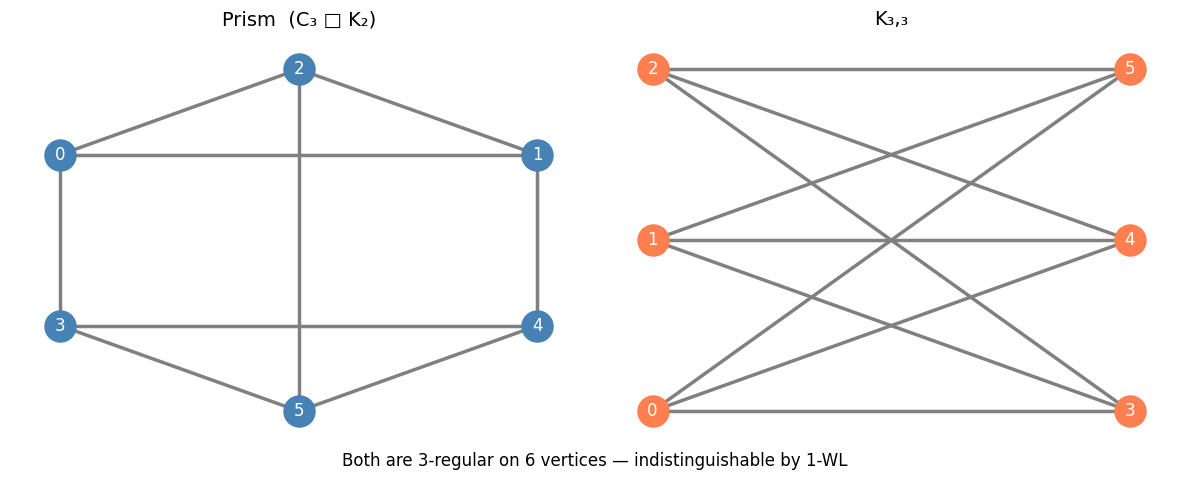

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Prism layout — two stacked triangles
pos_prism = {
    0: (-1,  1), 1: (1,  1), 2: (0,  2),
    3: (-1, -1), 4: (1, -1), 5: (0, -2),
}
nx.draw(prism, pos_prism, ax=axes[0],
        node_color='steelblue', node_size=500, font_color='white',
        width=2.5, edge_color='gray', with_labels=True)
axes[0].set_title('Prism  (C₃ □ K₂)', fontsize=14)

# K3,3 layout — bipartite
pos_k33 = nx.bipartite_layout(k33, nodes=[0, 1, 2])
nx.draw(k33, pos_k33, ax=axes[1],
        node_color='coral', node_size=500, font_color='white',
        width=2.5, edge_color='gray', with_labels=True)
axes[1].set_title('K₃,₃', fontsize=14)

plt.suptitle('Both are 3-regular on 6 vertices — indistinguishable by 1-WL', fontsize=12, y=0.02)
plt.tight_layout()
plt.show()

## 3. Run DRESS and compare fingerprints

In [5]:
res_prism = dress_graph(prism, set_attributes=True)
res_k33   = dress_graph(k33,   set_attributes=True)

ev_prism = sorted(round(v, 6) for v in res_prism.edge_dress)
ev_k33   = sorted(round(v, 6) for v in res_k33.edge_dress)

print(f"Prism fingerprint:  {ev_prism}")
print(f"K₃,₃  fingerprint:  {ev_k33}")
print(f"\nDistinguished? {ev_prism != ev_k33}")

Prism fingerprint:  [np.float64(0.921623), np.float64(0.921623), np.float64(0.921623), np.float64(1.709275), np.float64(1.709275), np.float64(1.709275), np.float64(1.709275), np.float64(1.709275), np.float64(1.709275)]
K₃,₃  fingerprint:  [np.float64(1.154701), np.float64(1.154701), np.float64(1.154701), np.float64(1.154701), np.float64(1.154701), np.float64(1.154701), np.float64(1.154701), np.float64(1.154701), np.float64(1.154701)]

Distinguished? True


## 4. Visualize DRESS edge values

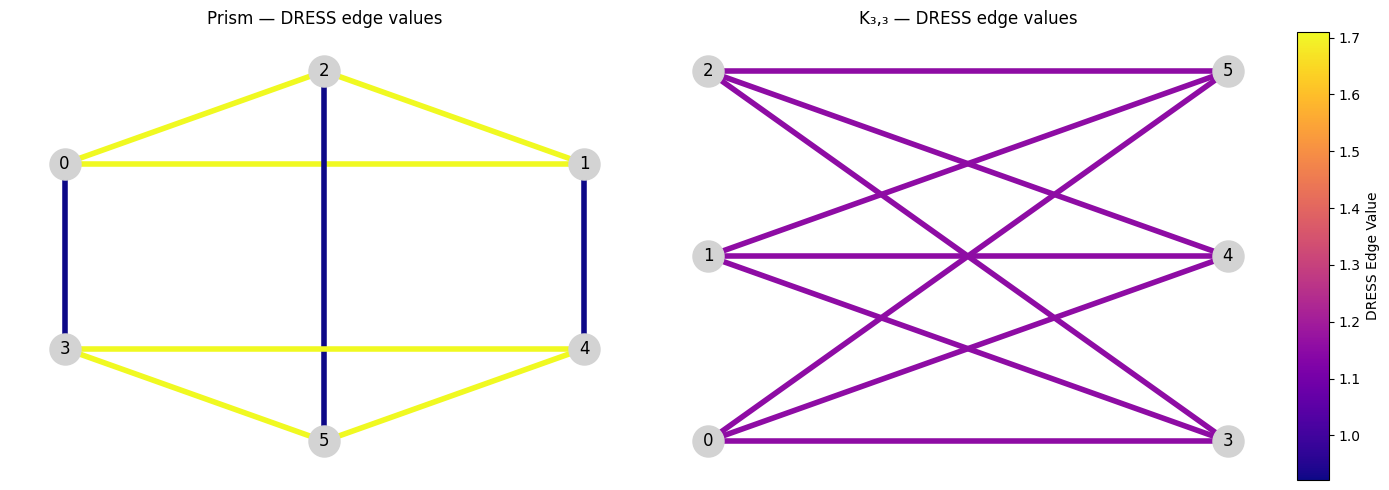

In [8]:
fig, (ax1, ax2, cax) = plt.subplots(1, 3, figsize=(14, 5),
                                     gridspec_kw={'width_ratios': [1, 1, 0.05]})

# Shared color range across both graphs
all_vals = list(res_prism.edge_dress) + list(res_k33.edge_dress)
vmin, vmax = min(all_vals), max(all_vals)

# Prism colored by DRESS
ev_p = [prism[u][v]['dress'] for u, v in prism.edges()]
nx.draw(prism, pos_prism, ax=ax1,
        node_color='lightgray', node_size=500,
        edge_color=ev_p, width=4, edge_cmap=plt.cm.plasma,
        edge_vmin=vmin, edge_vmax=vmax, with_labels=True)
ax1.set_title('Prism — DRESS edge values')

# K3,3 colored by DRESS
ev_k = [k33[u][v]['dress'] for u, v in k33.edges()]
nx.draw(k33, pos_k33, ax=ax2,
        node_color='lightgray', node_size=500,
        edge_color=ev_k, width=4, edge_cmap=plt.cm.plasma,
        edge_vmin=vmin, edge_vmax=vmax, with_labels=True)
ax2.set_title('K₃,₃ — DRESS edge values')

sm = plt.cm.ScalarMappable(cmap=plt.cm.plasma, norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])
fig.colorbar(sm, cax=cax, label='DRESS Edge Value')
plt.tight_layout()
plt.show()

### What does this show?

The Prism has **two distinct edge types** — triangle edges (high DRESS) and spoke/bridge edges (low DRESS). K₃,₃ has **all edges identical** (it's edge-transitive).

DRESS captures this structural difference as a simple sorted vector of edge values — a canonical fingerprint that 1-WL cannot produce.